# Этап 3 — Предсказание: реальное или нереальное блюдо

**Задача:** graph classification — отличить настоящий рецепт от «фейкового» (ингредиенты перемешаны из разных блюд).

**Baseline:** плотность связей в графе ингредиентов `I` + логистическая регрессия.

**GraphSAGE:** эмбеддинг рецепта через двудольный граф рецепт–ингредиент, бинарный классификатор.

**Интерпретация:** для фейковых рецептов — пары ингредиентов **без ребра** в `I` (несовместимость).

**Вывод:** названия ингредиентов **на русском**.

In [105]:
import ast
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

import ingredient_ru
import gnn_graph_classification
importlib.reload(ingredient_ru)
importlib.reload(gnn_graph_classification)
from ingredient_ru import preload_pool, ru, ru_list

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
from gnn_graph_classification import (
    incompatible_pairs,
    make_fake_recipes,
    train_graphsage_validity,
)

OUT = Path('output_graphs')
DATA = Path('full_dataset.csv')
if not DATA.exists():
    DATA = Path('data_sample.csv')
SEED = 42

print('Готово')

Готово


## 3.1 Загрузка графа и рецептов

In [106]:
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')
ing_set = {str(x) for x in I.nodes()}

importlib.reload(ingredient_ru)
from ingredient_ru import preload_pool
ingredient_ru._RUNTIME_RU.clear()
n_tr = preload_pool(ing_set)
print(f'Ингредиентов в графе: {len(ing_set):,}  (переведено: {n_tr:,})')

df = pd.read_csv(DATA, nrows=8000, usecols=['NER'])

recipes = []
for s in df['NER']:
    try:
        ings = [str(x).strip().lower() for x in ast.literal_eval(s) if isinstance(x, str)]
        ings = [x for x in ings if x in ing_set]
        if len(ings) >= 3:
            recipes.append(ings)
    except Exception:
        pass

print(f'Рецептов: {len(recipes):,}')

Ингредиентов в графе: 7,199  (переведено: 4,467)
Рецептов: 7,807


## 3.2 Признак «плотность связей» и метки

**Перед запуском:** выполните ячейку импортов и §3.1 (нужны `np`, `recipes`, `I`, `ing_set`).

**Реальные** — рецепты из датасета. **Фейковые** — ~50% ингредиентов заменены случайными из графа (имитация «смешали из разных блюд» → мало связей в `I`).

In [107]:
def edge_density(ings):
    pairs = 0
    edges = 0
    for i in range(len(ings)):
        for j in range(i + 1, len(ings)):
            pairs += 1
            if I.has_edge(ings[i], ings[j]):
                edges += 1
    return edges / pairs if pairs else 0.0


X_real = np.array([[edge_density(r), len(r)] for r in recipes])
y_real = np.ones(len(recipes))

# фейковые: ~50% ингредиентов заменены случайными (из других «блюд»)
fake = make_fake_recipes(recipes, ingredient_pool=sorted(ing_set), mix_ratio=0.5, seed=SEED)

X_fake = np.array([[edge_density(r), len(r)] for r in fake])
y_fake = np.zeros(len(fake))

X = np.vstack([X_real, X_fake])
y = np.concatenate([y_real, y_fake])
print('Пример реального:', ru_list(recipes[0][:6]))
print('  плотность связей =', round(edge_density(recipes[0]), 3))
print('Пример фейкового:', ru_list(fake[0][:6]))
print('  плотность связей =', round(edge_density(fake[0]), 3))

Пример реального: ['коричневый сахар', 'молоко', 'ваниль', 'орехи', 'сливочное масло']
  плотность связей = 1.0
Пример фейкового: ['сливочное масло', 'коричневый сахар', 'орехи', 'зернистая горчица', 'черничный йогурт']
  плотность связей = 0.5


## 3.3 Обучение и оценка

In [108]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=500)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)

print(f'Точность: {accuracy_score(y_te, pred):.3f}')
print(classification_report(y_te, pred, target_names=['нереальное', 'реальное']))

Точность: 0.962
              precision    recall  f1-score   support

  нереальное       0.96      0.96      0.96      1562
    реальное       0.96      0.96      0.96      1561

    accuracy                           0.96      3123
   macro avg       0.96      0.96      0.96      3123
weighted avg       0.96      0.96      0.96      3123



## 3.4 GraphSAGE (graph classification)

In [109]:
all_recipes = recipes + fake
y_all = np.concatenate([y_real, y_fake])

gs_result = train_graphsage_validity(
    all_recipes, y_all, I=I, hidden=64, epochs=50, seed=SEED,
)

print('GraphSAGE (real vs fake):')
print(f'  Accuracy: {gs_result.accuracy:.3f}')
print(f'  F1:       {gs_result.f1:.3f}')
print(f'  AUC:      {gs_result.auc:.3f}')

GraphSAGE (real vs fake):
  Accuracy: 0.902
  F1:       0.904
  AUC:      0.965


## 3.5 Сравнение baseline и GraphSAGE

,модель,accuracy,AUC
0,LogReg (плотность связей),0.961896,0.982911
1,GraphSAGE,0.902017,0.965398


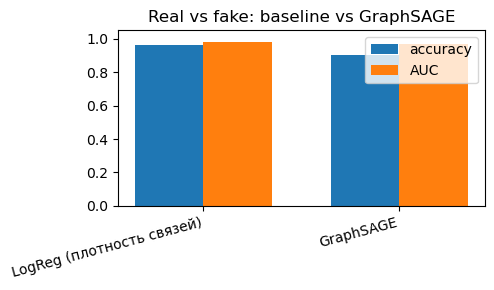

In [110]:
baseline_auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

cmp = pd.DataFrame([
    {'модель': 'LogReg (плотность связей)', 'accuracy': accuracy_score(y_te, pred), 'AUC': baseline_auc},
    {'модель': 'GraphSAGE', 'accuracy': gs_result.accuracy, 'AUC': gs_result.auc},
])
display(cmp)

fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(len(cmp))
w = 0.35
ax.bar(x - w/2, cmp['accuracy'], w, label='accuracy')
ax.bar(x + w/2, cmp['AUC'], w, label='AUC')
ax.set_xticks(x)
ax.set_xticklabels(cmp['модель'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Real vs fake: baseline vs GraphSAGE')
plt.tight_layout()
plt.savefig(OUT / 'dish_validity_compare.png', dpi=120)
plt.show()

## 3.6 Интерпретация: несовместимые пары в фейковых рецептах

Для фейкового рецепта показываем пары ингредиентов, которые **никогда не встречались вместе** в реальных рецептах (нет ребра в графе `I`).

In [111]:
print('Примеры фейковых рецептов и «странные» пары ингредиентов:\n')
for i in range(3):
    r = fake[i]
    bad = incompatible_pairs(r, I)
    print(f'Фейк #{i+1}: {ru_list(r[:8])}')
    print(f'  плотность связей = {edge_density(r):.3f}')
    if bad:
        show = bad[:5]
        pairs_ru = [f'{ru(a)} + {ru(b)}' for a, b in show]
        print(f'  несовместимые пары ({len(bad)} всего): {", ".join(pairs_ru)}')
    print()

Примеры фейковых рецептов и «странные» пары ингредиентов:

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', 'зернистая горчица', 'черничный йогурт']
  плотность связей = 0.500
  несовместимые пары (5 всего): сливочное масло + черничный йогурт, коричневый сахар + черничный йогурт, орехи + зернистая горчица, орехи + черничный йогурт, зернистая горчица + черничный йогурт

Фейк #2: ['говядина', 'сметана', 'цельные семена кориандра', 'четвертинки помидоров черри']
  плотность связей = 0.167
  несовместимые пары (5 всего): говядина + цельные семена кориандра, говядина + четвертинки помидоров черри, сметана + цельные семена кориандра, сметана + четвертинки помидоров черри, цельные семена кориандра + четвертинки помидоров черри

Фейк #3: ['перец', 'чесночный порошок', 'сливочное масло', 'свежие томатильо', 'пюре быстрого приготовления', 'молотая сухая горчица']
  плотность связей = 0.533
  несовместимые пары (7 всего): перец + молотая сухая горчица, чесночный порошок + свежие томатиль

## 3.7 График baseline (плотность связей)

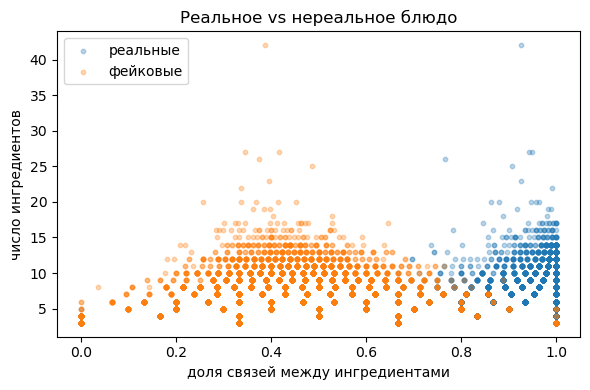

In [112]:
plt.figure(figsize=(6,4))
plt.scatter(X_real[:,0], X_real[:,1], alpha=0.3, s=10, label='реальные')
plt.scatter(X_fake[:,0], X_fake[:,1], alpha=0.3, s=10, label='фейковые')
plt.xlabel('доля связей между ингредиентами')
plt.ylabel('число ингредиентов')
plt.legend()
plt.title('Реальное vs нереальное блюдо')
plt.tight_layout()
plt.savefig(OUT / 'dish_validity.png', dpi=120)
plt.show()

## 3.8 HeteroGAT для real vs fake

Каждый рецепт — узел в двудольном графе; модель смотрит, какие ингредиенты и с каким весом связаны с рецептом, и предсказывает real или fake


In [113]:
import importlib
import gnn_cuisine_classification
importlib.reload(gnn_cuisine_classification)
from gnn_cuisine_classification import (
    build_bipartite_from_recipes,
    train_hetgat_cuisine,
)

# Структурные признаки ингредиентов
feat_df = pd.read_csv(OUT / 'node_features_structural.csv', index_col='ingredient')

# Строим двудольный граф из реальных + фейковых рецептов
G_val, recipe_ids_val, labels_val = build_bipartite_from_recipes(recipes, fake, I)
print(f'Граф: {G_val.number_of_nodes():,} узлов, {G_val.number_of_edges():,} рёбер')
print(f'Рецептов: {len(recipe_ids_val)} ({labels_val.count("real")} real, {labels_val.count("fake")} fake)')


Граф: 22,688 узлов, 113,787 рёбер
Рецептов: 15614 (7807 real, 7807 fake)


In [114]:
hg_val = train_hetgat_cuisine(
    G_nx       = G_val,
    recipe_ids = recipe_ids_val,
    labels     = labels_val,
    I_nx       = I,
    feat_df    = feat_df,
    hidden     = 128,
    heads      = 4,
    epochs     = 80,
    lr         = 3e-3,
    seed       = SEED,
    verbose    = True,
)
print(f'\nHeteroGAT (real vs fake):')
print(f'  Accuracy: {hg_val.accuracy:.3f}')
print(f'  F1:       {hg_val.f1:.3f}')
print(f'  AUC:      {hg_val.auc:.3f}')
print()
print(hg_val.report)


  [HeteroGAT] epoch  20  loss=0.6437  test_acc=0.736
  [HeteroGAT] epoch  40  loss=0.4320  test_acc=0.890
  [HeteroGAT] epoch  60  loss=0.2555  test_acc=0.943
  [HeteroGAT] epoch  80  loss=0.2300  test_acc=0.945

HeteroGAT (real vs fake):
  Accuracy: 0.945
  F1:       0.945
  AUC:      0.985

              precision    recall  f1-score   support

        fake       0.94      0.95      0.95      1579
        real       0.95      0.94      0.94      1544

    accuracy                           0.94      3123
   macro avg       0.95      0.94      0.94      3123
weighted avg       0.94      0.94      0.94      3123



## 3.9 Сравнение всех трёх моделей


,Модель,Accuracy,F1,AUC
0,LogReg (плотность связей),0.962,0.962,0.983
1,GraphSAGE,0.902,0.904,0.965
2,HeteroGAT,0.945,0.945,0.985


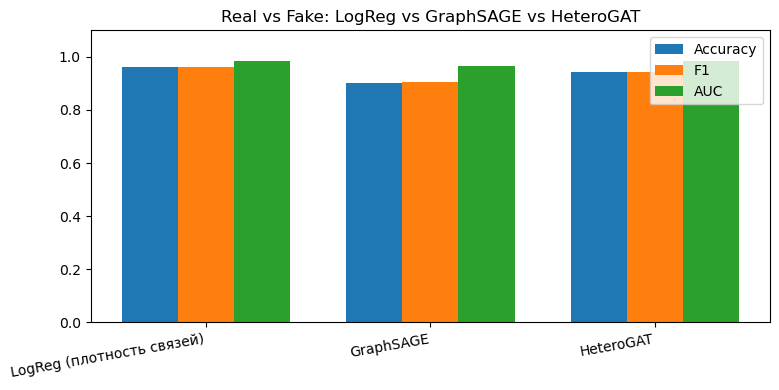

In [115]:
from sklearn.metrics import f1_score

comparison = pd.DataFrame([
    {'Модель': 'LogReg (плотность связей)',
     'Accuracy': accuracy_score(y_te, pred),
     'F1':       f1_score(y_te, pred, zero_division=0),
     'AUC':      roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])},
    {'Модель': 'GraphSAGE',
     'Accuracy': gs_result.accuracy,
     'F1':       gs_result.f1,
     'AUC':      gs_result.auc},
    {'Модель': 'HeteroGAT',
     'Accuracy': hg_val.accuracy,
     'F1':       hg_val.f1,
     'AUC':      hg_val.auc},
])
display(comparison.round(3))

x = np.arange(3)
w = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w, comparison['Accuracy'], w, label='Accuracy')
ax.bar(x,     comparison['F1'],       w, label='F1')
ax.bar(x + w, comparison['AUC'],      w, label='AUC')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Модель'], rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_title('Real vs Fake: LogReg vs GraphSAGE vs HeteroGAT')
plt.tight_layout()
plt.savefig(OUT / 'dish_validity_all_models.png', dpi=120)
plt.show()


## 3.10 Объяснение состава по графу I

Для каждого нереального рецепта смотрим на граф совместимости:

пары ингредиентов, которые никогда не встречались вместе в данных;
(ингредиенты, которые слабее всего связаны с остальными через общих соседей в графе.)


In [116]:
def find_odd_ingredient(recipe_ings, I, top_k=3):
    """
    Находит ингредиент, наименее связанный с остальными.
    Метрика: среднее число общих соседей с каждым другим ингредиентом рецепта.
    """
    ings = [x for x in recipe_ings if x in I]
    if len(ings) < 2:
        return []
    scores = {}
    for ing in ings:
        others = [x for x in ings if x != ing]
        cn_sum = sum(
            len(set(I.neighbors(ing)) & set(I.neighbors(o)))
            for o in others
        )
        scores[ing] = cn_sum / len(others)
    return sorted(scores, key=scores.get)[:top_k]

print('── Интерпретация фейковых рецептов ──\n')
for i in range(5):
    r = fake[i]
    bad_pairs = incompatible_pairs(r, I)
    odd_ings  = find_odd_ingredient(r, I)

    print(f'Фейк #{i+1}: {ru_list(r[:8])}')
    print(f'  Плотность связей: {edge_density(r):.3f}')

    if bad_pairs:
        shown = [f'{ru(a)} + {ru(b)}' for a, b in bad_pairs]
        print(f'  Несовместимые пары ({len(bad_pairs)}): {", ".join(shown)}')

    if odd_ings:
        print(f'  Ингредиент-аутсайдер: {ru_list(odd_ings)}')
    print()


── Интерпретация фейковых рецептов ──

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', 'зернистая горчица', 'черничный йогурт']
  Плотность связей: 0.500
  Несовместимые пары (5): сливочное масло + черничный йогурт, коричневый сахар + черничный йогурт, орехи + зернистая горчица, орехи + черничный йогурт, зернистая горчица + черничный йогурт
  Ингредиент-аутсайдер: ['черничный йогурт', 'зернистая горчица', 'орехи']

Фейк #2: ['говядина', 'сметана', 'цельные семена кориандра', 'четвертинки помидоров черри']
  Плотность связей: 0.167
  Несовместимые пары (5): говядина + цельные семена кориандра, говядина + четвертинки помидоров черри, сметана + цельные семена кориандра, сметана + четвертинки помидоров черри, цельные семена кориандра + четвертинки помидоров черри
  Ингредиент-аутсайдер: ['цельные семена кориандра', 'четвертинки помидоров черри', 'говядина']

Фейк #3: ['перец', 'чесночный порошок', 'сливочное масло', 'свежие томатильо', 'пюре быстрого приготовления', 'молотая суха

## 3.11 Среднее структурных признаков ингредиентов + LogReg

Складываем графовые метрики всех ингредиентов в один профиль блюда и проверяем, real это или fake.

In [117]:
# feat_df уже загружен в ячейке 3.8 — используем его
FEAT_COLS = ['degree', 'degree_w', 'pagerank', 'clustering', 'kcore', 'betweenness', 'log_freq']

def mean_pool(ings, feat_df, cols):
    """Средний вектор признаков ингредиентов рецепта (global mean pool)."""
    valid = [x for x in ings if x in feat_df.index]
    if valid:
        return feat_df.loc[valid, cols].mean().values
    return np.zeros(len(cols))

X_pool = np.vstack([
    [mean_pool(r, feat_df, FEAT_COLS) for r in recipes],
    [mean_pool(r, feat_df, FEAT_COLS) for r in fake],
])

X_pool_tr, X_pool_te, ypool_tr, ypool_te = train_test_split(
    X_pool, y, test_size=0.2, random_state=42, stratify=y
)
clf_pool = LogisticRegression(max_iter=500)
clf_pool.fit(X_pool_tr, ypool_tr)
pred_pool = clf_pool.predict(X_pool_te)

pool_acc = accuracy_score(ypool_te, pred_pool)
pool_auc = roc_auc_score(ypool_te, clf_pool.predict_proba(X_pool_te)[:, 1])
print(f'MeanPool + LogReg:  acc={pool_acc:.3f}  AUC={pool_auc:.3f}')
print(classification_report(ypool_te, pred_pool, target_names=['фейк', 'реальный']))


MeanPool + LogReg:  acc=0.893  AUC=0.944
              precision    recall  f1-score   support

        фейк       0.89      0.89      0.89      1562
    реальный       0.89      0.89      0.89      1561

    accuracy                           0.89      3123
   macro avg       0.89      0.89      0.89      3123
weighted avg       0.89      0.89      0.89      3123



## 3.12 SHAP 

SHAP объясняет предсказания MeanPool-модели: какой структурный признак ингредиентов  
сдвигает рецепт в сторону face или real.


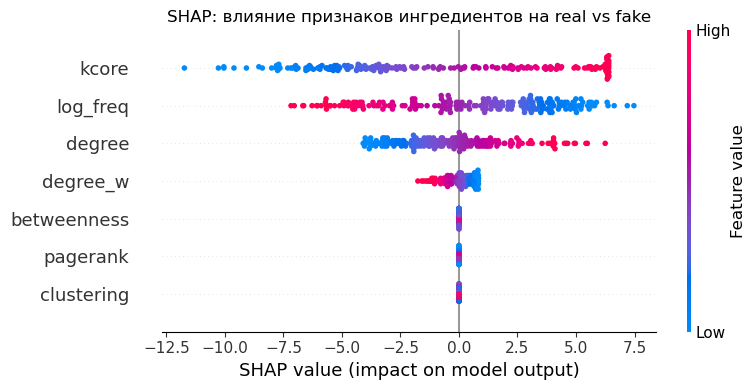

Фейк: ['сливочное масло', 'коричневый сахар', 'орехи', 'зернистая горчица', 'черничный йогурт']
Предсказание: фейк

SHAP-вклад каждого признака (+ = к реальному, − = к фейку):
  kcore           -2.7775  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [122]:
import warnings

# LinearExplainer быстрее и точнее KernelExplainer для LogReg
explainer  = shap.LinearExplainer(clf_pool, X_pool_tr, feature_names=FEAT_COLS)
shap_vals  = explainer(X_pool_te[:200])

# Summary plot: глобальная важность признаков
with warnings.catch_warnings():
    warnings.filterwarnings(
        'ignore',
        category=FutureWarning,
        message=r'.*NumPy global RNG was seeded.*',
    )
    shap.summary_plot(
        shap_vals, X_pool_te[:200], feature_names=FEAT_COLS,
        show=False, plot_size=(8, 4),
    )
plt.title('SHAP: влияние признаков ингредиентов на real vs fake')
plt.tight_layout()
plt.savefig(OUT / 'shap_summary.png', dpi=120)
plt.show()

# Объяснение для одного фейкового рецепта
i_explain = 0
x_fake_pool = mean_pool(fake[i_explain], feat_df, FEAT_COLS).reshape(1, -1)
sv_one = explainer(x_fake_pool)

print(f'Фейк: {ru_list(fake[i_explain][:8])}')
print(f'Предсказание: {"реальный" if clf_pool.predict(x_fake_pool)[0] == 1 else "фейк"}')
print()
print('SHAP-вклад каждого признака (+ = к реальному, − = к фейку):')
for feat, val in sorted(zip(FEAT_COLS, sv_one.values[0]), key=lambda x: abs(x[1]), reverse=True):
    bar = '█' * int(abs(val) * 500)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:<15} {sign}{abs(val):.4f}  {bar}')


## 3.13 Какие ингредиенты HeteroGAT учитывает сильнее

In [123]:
from gnn_cuisine_classification import top_attention_ingredients

print('── HeteroGAT: ингредиенты по важности для решения ──\n')
n_real = len(recipes)
for k in range(3):
    ridx = n_real + k                      # индекс фейкового рецепта #k в data['recipe']
    top = top_attention_ingredients(
        hg_val.model, hg_val.data, ridx, hg_val.ing_names, top_k=5,
    )
    print(f'Фейк #{k+1}: {ru_list(fake[k][:8])}')
    for name, score in top:
        bar = '█' * int(score * 30)
        print(f'   attn={score:.3f} {bar} {ru(name)}')
    print()

── HeteroGAT: ингредиенты по важности для решения ──

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', 'зернистая горчица', 'черничный йогурт']
   attn=0.506 ███████████████ сливочное масло
   attn=0.155 ████ коричневый сахар
   attn=0.122 ███ орехи
   attn=0.109 ███ зернистая горчица
   attn=0.108 ███ черничный йогурт

Фейк #2: ['говядина', 'сметана', 'цельные семена кориандра', 'четвертинки помидоров черри']
   attn=0.348 ██████████ сметана
   attn=0.232 ██████ говядина
   attn=0.211 ██████ четвертинки помидоров черри
   attn=0.210 ██████ цельные семена кориандра

Фейк #3: ['перец', 'чесночный порошок', 'сливочное масло', 'свежие томатильо', 'пюре быстрого приготовления', 'молотая сухая горчица']
   attn=0.479 ██████████████ сливочное масло
   attn=0.149 ████ перец
   attn=0.097 ██ чесночный порошок
   attn=0.092 ██ свежие томатильо
   attn=0.092 ██ пюре быстрого приготовления



## 3.14 GraphSAGE: среднее по ингредиентам

GraphSAGE обучается заново. На выход идёт не узел рецепта (§3.4), а среднее по ингредиентам этого рецепта.


In [120]:
import importlib, gnn_graph_classification
importlib.reload(gnn_graph_classification)
from gnn_graph_classification import train_graphsage_validity

gs_pool = train_graphsage_validity(
    all_recipes, y_all, I=I, hidden=64, epochs=50, seed=SEED, readout='mean',
)
print('GraphSAGE, среднее по ингредиентам (real vs fake):')
print(f'  Accuracy: {gs_pool.accuracy:.3f}')
print(f'  F1:       {gs_pool.f1:.3f}')
print(f'  AUC:      {gs_pool.auc:.3f}')

GraphSAGE + global_mean_pool (real vs fake):
  Accuracy: 0.888
  F1:       0.892
  AUC:      0.955


## 3.15 Counterfactual: подмена/удаление ингредиента → рост P(фейк)

Берём обученную модель, по очереди убираем каждый ингредиент рецепта и смотрим, как меняется вероятность. признаков).

In [121]:
from gnn_graph_classification import counterfactual_culprits

# модель из §3.14 — чувствительнее к удалению ингредиента
print('── Counterfactual: убираем ингредиент → как меняется P(фейк) ──\n')
for k in range(3):
    base, culprits = counterfactual_culprits(gs_pool.model, fake[k], I)
    if base is None:
        continue
    print(f'Фейк #{k+1}: {ru_list(fake[k][:8])}')
    print(f'  P(фейк) исходно: {base:.3f}')
    for ing, delta in culprits[:3]:
        arrow = 'снижает фейк' if delta > 0 else 'повышает фейк'
        print(f'   убрать {ru(ing):<22} Δ={delta:+.3f}  ({arrow})')
    print()

── Counterfactual: убираем ингредиент → как меняется P(фейк) ──

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', 'зернистая горчица', 'черничный йогурт']
  P(фейк) исходно: 0.052
   убрать черничный йогурт       Δ=+0.033  (снижает фейк)
   убрать зернистая горчица      Δ=+0.013  (снижает фейк)
   убрать орехи                  Δ=-0.021  (повышает фейк)

Фейк #2: ['говядина', 'сметана', 'цельные семена кориандра', 'четвертинки помидоров черри']
  P(фейк) исходно: 0.059
   убрать цельные семена кориандра Δ=+0.032  (снижает фейк)
   убрать четвертинки помидоров черри Δ=+0.015  (снижает фейк)
   убрать говядина               Δ=-0.032  (повышает фейк)

Фейк #3: ['перец', 'чесночный порошок', 'сливочное масло', 'свежие томатильо', 'пюре быстрого приготовления', 'молотая сухая горчица']
  P(фейк) исходно: 0.115
   убрать молотая сухая горчица  Δ=+0.043  (снижает фейк)
   убрать свежие томатильо       Δ=+0.035  (снижает фейк)
   убрать пюре быстрого приготовления Δ=+0.029  (снижает фе